# Drivers and lead time

Personal notes: `eda/talk/N_drivers.md`.

Wei covers flood-mask structure (pixels about 250 m) and a first look at station 100205 plus Lake Albert.
This notebook is the **local AA join**: unusual water in Jonglei / Unity / Upper Nile, then rain, lakes, the SSD gauge, Albert.

**AA question:** does discharge or lake level rise *before* unusual inundation, enough to act?

Same-month correlation is not a forecast. Negative rain corr (cells above) already showed the naive monthly join can be the wrong shape.


In [1]:
from pathlib import Path
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

%matplotlib inline

ROOT = Path(".").resolve()
if not (ROOT / "raw_data").exists():
    ROOT = Path("..").resolve()
DATA = ROOT / "raw_data"
OUT = ROOT / "eda" / "outputs" / "drivers"
OUT.mkdir(parents=True, exist_ok=True)

# corridor covering jonglei + upper nile
BBOX = {"lat_min": 5.72, "lat_max": 12.24, "lon_min": 28.69, "lon_max": 35.02}
YEARS = list(range(2020, 2025))
TILES = ["h20v08", "h21v08"]


In [2]:
# pixel-days this time: more water-days in a month = bigger flood month
rows = []
for year in YEARS:
    parts = []
    for tile in TILES:
        path = DATA / "flood_masks" / "compact_unusual" / f"flood_events_{tile}_{year}.parquet"
        df = pd.read_parquet(path, columns=["date", "lat", "lon"])
        parts.append(df)
    df = pd.concat(parts, ignore_index=True)
    df["date"] = pd.to_datetime(df["date"].astype(str))
    m = (
        (df["lat"] >= BBOX["lat_min"]) & (df["lat"] <= BBOX["lat_max"]) &
        (df["lon"] >= BBOX["lon_min"]) & (df["lon"] <= BBOX["lon_max"])
    )
    df = df.loc[m]
    df["month"] = df["date"].dt.to_period("M").astype(str)
    g = df.groupby("month").size().reset_index(name="unusual_pixel_days")
    rows.append(g)
    print(year, "rows_in_bbox", len(df))
flood_m = pd.concat(rows, ignore_index=True)
flood_m["date"] = pd.to_datetime(flood_m["month"])
flood_m = flood_m.sort_values("date")
flood_m.to_csv(OUT / "unusual_flood_monthly.csv", index=False)
flood_m.head()


2020 rows_in_bbox 1820189


2021 rows_in_bbox 2930668


2022 rows_in_bbox 7559159


2023 rows_in_bbox 11792193


2024 rows_in_bbox 9162431


,month,unusual_pixel_days,date
0,2020-01,611742,2020-01-01
1,2020-02,541309,2020-02-01
2,2020-03,138189,2020-03-01
3,2020-04,5078,2020-04-01
4,2020-05,6199,2020-05-01


In [3]:
# hydroweb txt uses JASN1/2/3 and SEN6A. without them the series dies around 2002
MISSIONS = {
    "TOPEX", "JASON-1", "JASON-2", "JASON-3", "J1", "J2", "J3",
    "S3A", "S3B", "S6A", "ENVISAT", "ERS-1", "ERS-2",
    "JASN1", "JASN2", "JASN3", "SEN6A",
}
COL_NAMES = [
    "mission", "cycle", "date", "hour", "minute",
    "height_wrt_ref", "height_err", "backscatter_ku",
    "wet_tropo_corr", "iono_corr", "dry_tropo_corr",
    "mode1", "mode2", "ice_flag", "height_egm2008", "data_source_flag",
]

def load_lake_txt(name):
    fname = DATA / "Water levels lakes" / f"water_level_{name}.txt"
    lines = []
    with open(fname, "r", encoding="latin-1") as f:
        for line in f:
            tok = line.strip().split()[0] if line.strip() else ""
            if tok in MISSIONS:
                lines.append(line.strip())
    df = pd.read_csv(io.StringIO("\n".join(lines)), sep=r"\s+", names=COL_NAMES, engine="python")
    df["datetime"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
    df = df.dropna(subset=["datetime"]).set_index("datetime").sort_index()
    s = df["height_egm2008"].resample("MS").mean()
    # kyoga has parse spikes; drop heights far from the median
    med = s.median()
    s = s.where((s - med).abs() < 50)
    return s

lake_v = load_lake_txt("victoria")
lake_k = load_lake_txt("Kyoga")
print("victoria", lake_v.dropna().index.min(), "to", lake_v.dropna().index.max())
print("kyoga", lake_k.dropna().index.min(), "to", lake_k.dropna().index.max())


victoria 1992-10-01 00:00:00 to 2026-05-01 00:00:00
kyoga 1992-09-01 00:00:00 to 2026-05-01 00:00:00


In [4]:
# ERA5 files use latitude going north to south, so the slice order depends on that
rain_rows = []
for year in YEARS:
    path = DATA / "rainfall and runoff" / f"ERA5_{year}.nc"
    ds = xr.open_dataset(path)
    tp = ds["tp"]
    lat_name = "latitude" if "latitude" in tp.coords else "lat"
    lon_name = "longitude" if "longitude" in tp.coords else "lon"
    time_name = "valid_time" if "valid_time" in tp.coords else "time"
    lat0 = float(tp[lat_name][0])
    lat1 = float(tp[lat_name][-1])
    lat_slice = slice(BBOX["lat_max"], BBOX["lat_min"]) if lat0 > lat1 else slice(BBOX["lat_min"], BBOX["lat_max"])
    tp_s = tp.sel({lat_name: lat_slice, lon_name: slice(BBOX["lon_min"], BBOX["lon_max"])})
    # tp is in metres; *1000 is a mm-ish scale for the plot, not a rain-gauge total
    monthly = (tp_s.mean(dim=[lat_name, lon_name]) * 1000).resample({time_name: "MS"}).mean()
    for t, val in zip(monthly[time_name].values, monthly.values):
        rain_rows.append({"date": pd.to_datetime(t), "tp_mm_mean": float(val)})
    ds.close()
    print("rain", year)
rain = pd.DataFrame(rain_rows).drop_duplicates("date").sort_values("date")
rain.head()


rain 2020


rain 2021


rain 2022


rain 2023


rain 2024


,date,tp_mm_mean
0,2020-01-01,0.003189
1,2020-02-01,0.003505
2,2020-03-01,0.008823
3,2020-04-01,0.025332
4,2020-05-01,0.095743


In [5]:
# shift(1) = rain/lake last month vs flood this month (naive 1-month lead)
out = flood_m.set_index("date")[["unusual_pixel_days"]].copy()
out["lake_victoria"] = lake_v.reindex(out.index)
out["lake_kyoga"] = lake_k.reindex(out.index)
out["tp_mm_mean"] = rain.set_index("date")["tp_mm_mean"].reindex(out.index)
out.to_csv(OUT / "drivers_monthly.csv")
display(out.tail(12))

for col in ["lake_victoria", "lake_kyoga", "tp_mm_mean"]:
    a = out[["unusual_pixel_days", col]].dropna()
    if len(a) > 6:
        c0 = a["unusual_pixel_days"].corr(a[col])
        c1 = a["unusual_pixel_days"].corr(a[col].shift(1))
        print(f"{col}: same_month={c0:.3f}  rain_or_lake_leads_1m={c1:.3f}  n={len(a)}")


,unusual_pixel_days,lake_victoria,lake_kyoga,tp_mm_mean
date,,,,
2024-01-01,1885954,1136.990000,1035.003333,0.000693
2024-02-01,1086957,1137.060000,1034.876667,0.001878
2024-03-01,900728,1137.080000,1035.170000,0.005044
2024-04-01,609509,1137.250000,1035.123333,0.030077
2024-05-01,382752,1137.473333,1035.626667,0.040827
2024-06-01,170780,1137.395000,1035.720000,0.057029
2024-07-01,179021,1137.146667,1035.806667,0.204508
2024-08-01,135033,1137.060000,NaN,0.285048
2024-09-01,365676,1136.920000,1036.135000,0.159699


lake_victoria: same_month=-0.318  rain_or_lake_leads_1m=-0.481  n=59
lake_kyoga: same_month=-0.409  rain_or_lake_leads_1m=-0.333  n=52
tp_mm_mean: same_month=-0.573  rain_or_lake_leads_1m=-0.406  n=60


## How to read the plots

Blue = unusual flood pixel-days per month. Orange = rain (or lake level) on the other axis.

Rain same-month corr was about **-0.65**. That can happen if peak unusual water is not the same month as peak local ERA5 rain (upstream delay, Sudd storage, dry-season water still labelled unusual).

**Do not say** "rain does not matter". **Do say** "we do not yet have a clean lead-time signal from this monthly overlap".


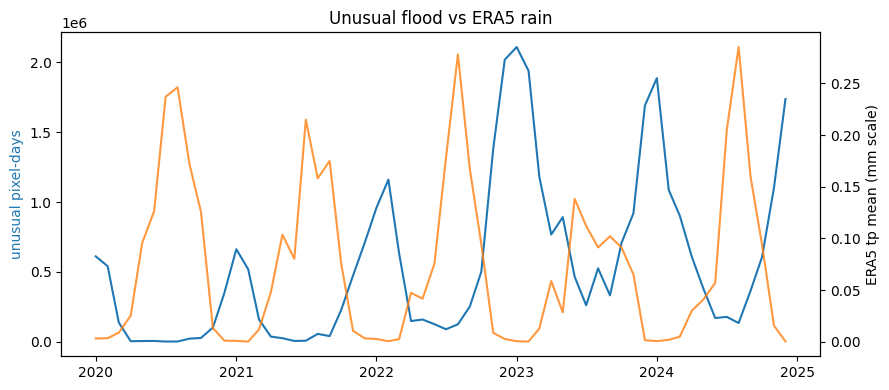

In [6]:
# two y-axes because pixel-days and rain are different units
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(out.index, out["unusual_pixel_days"], color="C0")
ax1.set_ylabel("unusual pixel-days", color="C0")
ax2 = ax1.twinx()
ax2.plot(out.index, out["tp_mm_mean"], color="C1", alpha=0.8)
ax2.set_ylabel("ERA5 tp mean (mm scale)")
ax1.set_title("Unusual flood vs ERA5 rain")
fig.tight_layout()
fig.savefig(OUT / "01_flood_vs_rain.png", dpi=140)
plt.show()


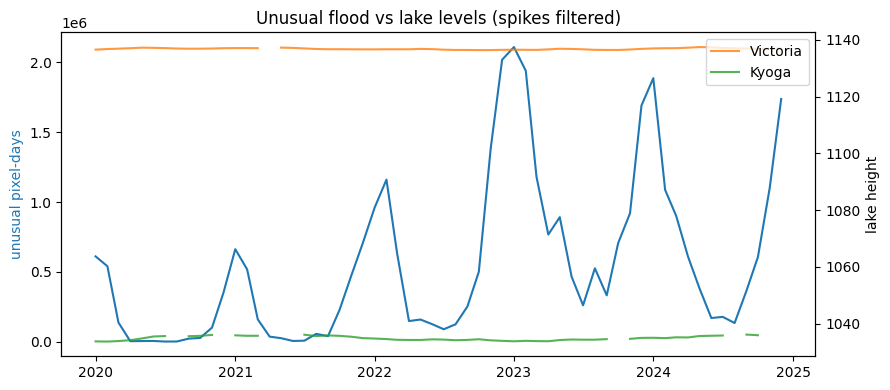

In [7]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(out.index, out["unusual_pixel_days"], color="C0")
ax1.set_ylabel("unusual pixel-days", color="C0")
ax2 = ax1.twinx()
ax2.plot(out.index, out["lake_victoria"], color="C1", alpha=0.8, label="Victoria")
ax2.plot(out.index, out["lake_kyoga"], color="C2", alpha=0.8, label="Kyoga")
ax2.set_ylabel("lake height")
ax2.legend(loc="upper right")
ax1.set_title("Unusual flood vs lake levels (spikes filtered)")
fig.tight_layout()
fig.savefig(OUT / "02_flood_vs_lakes.png", dpi=140)
plt.show()


## Complementary hydro: gauge 100205 and Lake Albert (10 years)

Station **100205** (Dartmouth area id, station nr 334) is the South Sudan gauge in the pack, at about lat 9.6, lon 31.6 (White Nile / Upper Nile, near Malakal). Wei already plotted it. We reuse it against **our** flood series so the group does not have two disconnected stories.

Complementary on purpose:
- flood = unusual pixel-days inside our bboxes, not a national pixel dump
- split Jonglei vs Upper Nile (the gauge sits in Upper Nile, so it should track UN more than Sudd/Jonglei if the story is riverine)
- unusual vs recurring (does the gauge follow seasonal wetland water or the rare pattern?)
- lag 0 to 6 months (lead time, not only same month)
- Lake Albert monthly mean vs the same flood series (Victoria/Kyoga were above)

Years: 2016-2025. Pixel size reminder: NASA flood masks are about 250 m, so pixel-days are area-ish, not people.


In [8]:
# 10 recent years that overlap floods, the gauge, and Albert
HYDRO_YEARS = list(range(2016, 2026))
STATION_ID = 100205
JONGLEI_BBOX = {"lat_min": 5.72, "lat_max": 9.52, "lon_min": 30.21, "lon_max": 35.02}
UN_BBOX = {"lat_min": 7.99, "lat_max": 12.24, "lon_min": 30.76, "lon_max": 34.15}
UNITY_BBOX = {"lat_min": 7.07, "lat_max": 10.29, "lon_min": 28.69, "lon_max": 30.85}


def monthly_flood(kind, years, bbox):
    # kind: unusual or recurring. pixel-days = rows after bbox filter
    folder = "compact_unusual" if kind == "unusual" else "compact_recurring"
    parts = []
    for year in years:
        frames = []
        for tile in TILES:
            path = DATA / "flood_masks" / folder / f"flood_events_{tile}_{year}.parquet"
            if not path.exists():
                continue
            df = pd.read_parquet(path, columns=["date", "lat", "lon"])
            frames.append(df)
        if not frames:
            continue
        df = pd.concat(frames, ignore_index=True)
        df["date"] = pd.to_datetime(df["date"].astype(str))
        m = (
            (df["lat"] >= bbox["lat_min"]) & (df["lat"] <= bbox["lat_max"]) &
            (df["lon"] >= bbox["lon_min"]) & (df["lon"] <= bbox["lon_max"])
        )
        df = df.loc[m]
        g = df.groupby(df["date"].dt.to_period("M")).size()
        parts.append(g)
        print(kind, year, "rows", len(df))
    s = pd.concat(parts).groupby(level=0).sum()
    s.index = s.index.to_timestamp()
    s.name = "pixel_days"
    return s.sort_index()


unusual_cor = monthly_flood("unusual", HYDRO_YEARS, BBOX)
unusual_jg = monthly_flood("unusual", HYDRO_YEARS, JONGLEI_BBOX)
unusual_un = monthly_flood("unusual", HYDRO_YEARS, UN_BBOX)
unusual_unity = monthly_flood("unusual", HYDRO_YEARS, UNITY_BBOX)
recurring_cor = monthly_flood("recurring", HYDRO_YEARS, BBOX)
print("months unusual corridor", len(unusual_cor))


unusual 2016 rows 354744
unusual 2017 rows 247234


unusual 2018 rows 260495
unusual 2019 rows 307920


unusual 2020 rows 1820189


unusual 2021 rows 2930668


unusual 2022 rows 7559159


...

recurring 2021 rows 426961


recurring 2022 rows 403343


recurring 2023 rows 369414


recurring 2024 rows 394677


recurring 2025 rows 331527
months unusual corridor 120


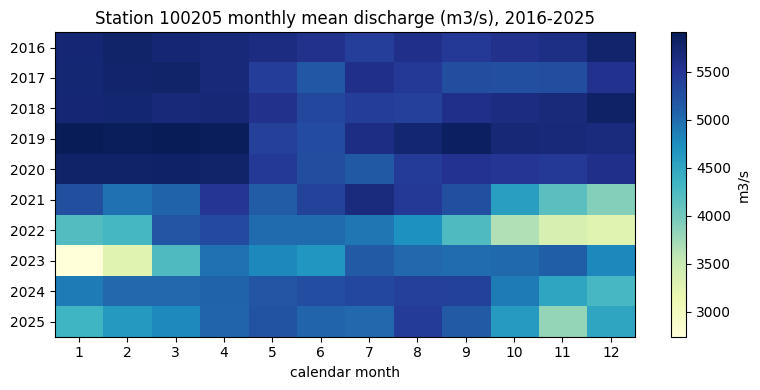

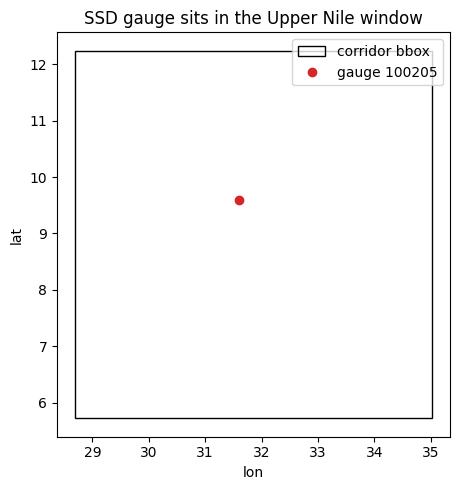

In [9]:
disc = pd.read_csv(DATA / "Darthmouth Flood Observatory" / f"{STATION_ID}_discharge.csv")
disc["Date"] = pd.to_datetime(disc["Date"])
q = disc.set_index("Date")["Discharge (m3/s)"].resample("MS").mean()
q = q.loc[str(HYDRO_YEARS[0]):str(HYDRO_YEARS[-1])]
q.name = "discharge_m3s"

# year x calendar-month: seasonal shape of the gauge
q_ym = q.to_frame()
q_ym["year"] = q_ym.index.year
q_ym["month"] = q_ym.index.month
grid = q_ym.pivot(index="year", columns="month", values="discharge_m3s")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(grid.values, aspect="auto", cmap="YlGnBu")
ax.set_yticks(range(len(grid.index)))
ax.set_yticklabels(grid.index)
ax.set_xticks(range(12))
ax.set_xticklabels(list(range(1, 13)))
ax.set_xlabel("calendar month")
ax.set_title("Station 100205 monthly mean discharge (m3/s), 2016-2025")
fig.colorbar(im, ax=ax, label="m3/s")
fig.tight_layout()
fig.savefig(OUT / "03_q100205_year_month.png", dpi=140)
plt.show()

from matplotlib.patches import Rectangle
# station vs our two bboxes (gauge is in Upper Nile)
fig, ax = plt.subplots(figsize=(6, 5))
ax.add_patch(Rectangle((BBOX["lon_min"], BBOX["lat_min"]),
                           BBOX["lon_max"]-BBOX["lon_min"], BBOX["lat_max"]-BBOX["lat_min"],
                           fill=False, label="corridor bbox"))
ax.plot(31.6, 9.6, "o", color="C3", label="gauge 100205")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title("SSD gauge sits in the Upper Nile window")
ax.legend()
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(OUT / "04_gauge_on_bbox.png", dpi=140)
plt.show()


/tmp/ipykernel_30208/1131191663.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  d = pd.concat([flood, driver], axis=1).dropna()
/tmp/ipykernel_30208/1131191663.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  d = pd.concat([flood, driver], axis=1).dropna()


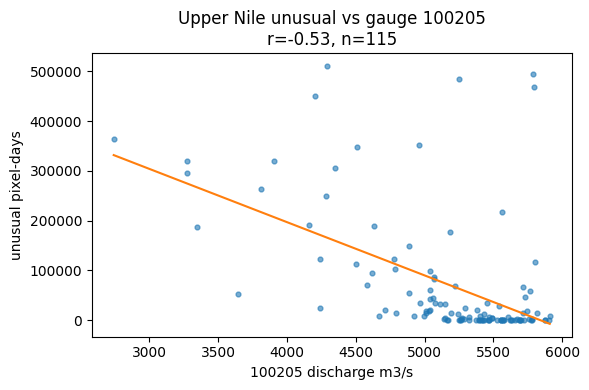

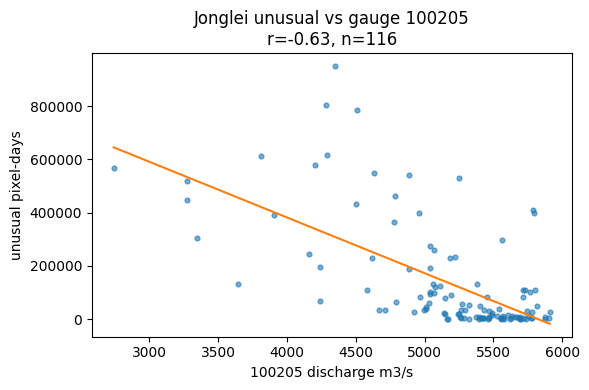

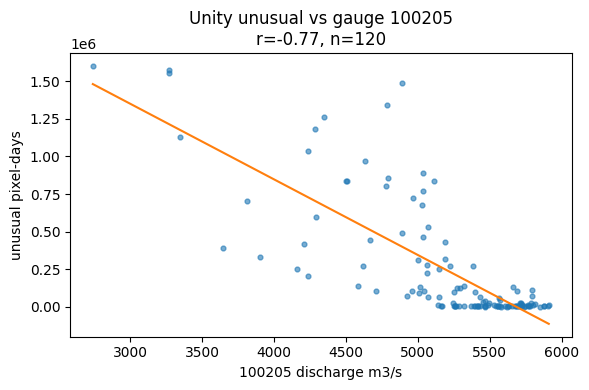

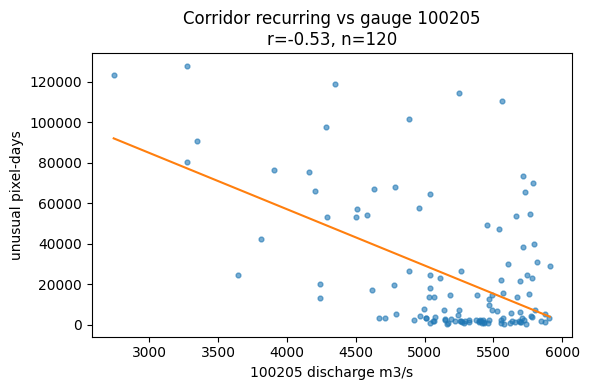

same-month r  UN unusual -0.5263573581785508
same-month r  Jonglei unusual -0.6341326845990866
same-month r  Unity unusual -0.7689730007290518
same-month r  corridor unusual -0.7759663256681796
same-month r  corridor recurring -0.5343991772838449


In [10]:
def overlay(flood, driver, name):
    d = pd.concat([flood, driver], axis=1).dropna()
    d.columns = ["flood", "driver"]
    return d


def scatter_fit(d, xlabel, title, fname):
    from numpy.polynomial.polynomial import polyfit
    x = d["driver"].to_numpy()
    y = d["flood"].to_numpy()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(x, y, s=12, alpha=0.6)
    if len(d) > 3:
        b, a = polyfit(x, y, 1)  # y = a*x + b
        xs = np.linspace(x.min(), x.max(), 50)
        ax.plot(xs, a * xs + b, color="C1")
        r = d["flood"].corr(d["driver"])
        ax.set_title(f"{title}\nr={r:.2f}, n={len(d)}")
    else:
        ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("unusual pixel-days")
    fig.tight_layout()
    fig.savefig(OUT / fname, dpi=140)
    plt.show()


d_un = overlay(unusual_un, q, "un")
d_jg = overlay(unusual_jg, q, "jg")
d_cor = overlay(unusual_cor, q, "cor")
d_unity = overlay(unusual_unity, q, "unity")
d_rec = overlay(recurring_cor, q, "rec")

scatter_fit(d_un, "100205 discharge m3/s", "Upper Nile unusual vs gauge 100205", "05_scatter_un_vs_q.png")
scatter_fit(d_jg, "100205 discharge m3/s", "Jonglei unusual vs gauge 100205", "06_scatter_jg_vs_q.png")
scatter_fit(d_unity, "100205 discharge m3/s", "Unity unusual vs gauge 100205", "06b_scatter_unity_vs_q.png")
scatter_fit(d_rec, "100205 discharge m3/s", "Corridor recurring vs gauge 100205", "07_scatter_rec_vs_q.png")
print("same-month r  UN unusual", d_un["flood"].corr(d_un["driver"]))
print("same-month r  Jonglei unusual", d_jg["flood"].corr(d_jg["driver"]))
print("same-month r  Unity unusual", d_unity["flood"].corr(d_unity["driver"]))
print("same-month r  corridor unusual", d_cor["flood"].corr(d_cor["driver"]))
print("same-month r  corridor recurring", d_rec["flood"].corr(d_rec["driver"]))


/tmp/ipykernel_30208/3280519231.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  d = pd.concat([flood, driver], axis=1).dropna()
/tmp/ipykernel_30208/3280519231.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  d = pd.concat([flood, driver], axis=1).dropna()


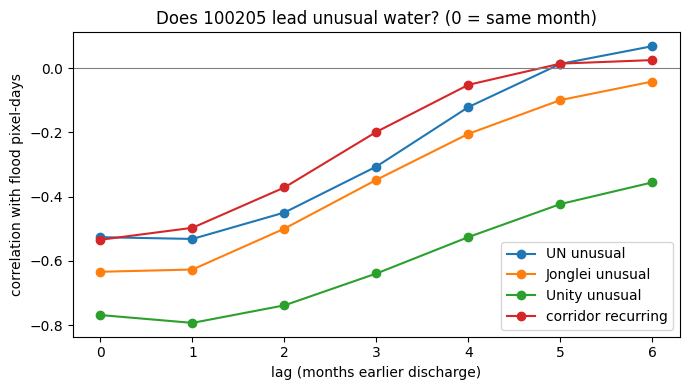

,lag_months,r,n
0,0,-0.526357,115
1,1,-0.531882,114
2,2,-0.449540,113
3,3,-0.306246,112
4,4,-0.121048,111
5,5,0.013437,110
6,6,0.068585,109


In [11]:
def lag_corr(flood, driver, max_lag=6):
    # lag k: driver from k months earlier vs flood now (k>0 means lead time)
    d = pd.concat([flood, driver], axis=1).dropna()
    d.columns = ["flood", "driver"]
    rows = []
    for k in range(0, max_lag + 1):
        r = d["flood"].corr(d["driver"].shift(k))
        rows.append({"lag_months": k, "r": r, "n": int(d["driver"].shift(k).notna().sum())})
    return pd.DataFrame(rows)


lags_un = lag_corr(unusual_un, q)
lags_jg = lag_corr(unusual_jg, q)
lags_unity = lag_corr(unusual_unity, q)
lags_rec = lag_corr(recurring_cor, q)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lags_un.lag_months, lags_un.r, marker="o", label="UN unusual")
ax.plot(lags_jg.lag_months, lags_jg.r, marker="o", label="Jonglei unusual")
ax.plot(lags_unity.lag_months, lags_unity.r, marker="o", label="Unity unusual")
ax.plot(lags_rec.lag_months, lags_rec.r, marker="o", label="corridor recurring")
ax.axhline(0, color="0.5", linewidth=0.8)
ax.set_xlabel("lag (months earlier discharge)")
ax.set_ylabel("correlation with flood pixel-days")
ax.set_title("Does 100205 lead unusual water? (0 = same month)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "08_lag_q_vs_flood.png", dpi=140)
plt.show()
display(lags_un)


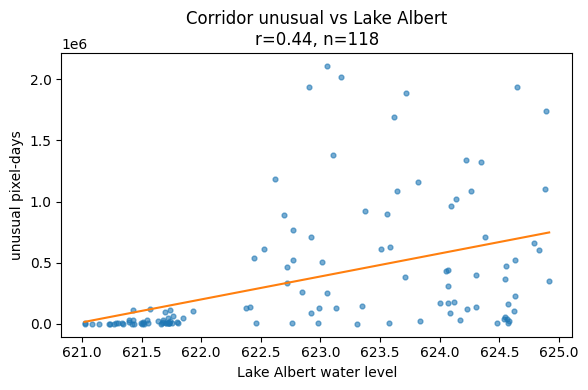

/tmp/ipykernel_30208/3280519231.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  d = pd.concat([flood, driver], axis=1).dropna()


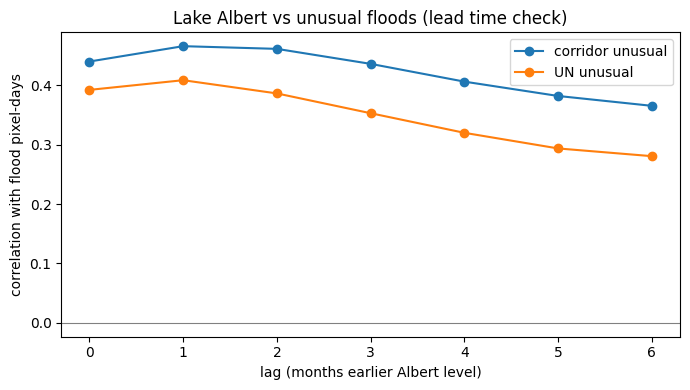

same-month r Albert vs corridor unusual 0.43978318672746963


,lag_months,r,n
0,0,0.439783,118
1,1,0.465628,117
2,2,0.461093,116
3,3,0.435853,115
4,4,0.405962,114
5,5,0.381821,113
6,6,0.365233,112


In [12]:
# albert: datetime is a data variable in the nc, not a coordinate
ds = xr.open_dataset(DATA / "Water levels lakes" / "water_level_altimetry_Albert.nc")
albert = pd.DataFrame({
    "datetime": pd.to_datetime(ds["datetime"].values.astype(str)),
    "water_level": ds["water_level"].values.astype(float),
}).dropna().set_index("datetime").sort_index()["water_level"].resample("MS").mean()
ds.close()
albert = albert.loc[str(HYDRO_YEARS[0]):str(HYDRO_YEARS[-1])]
albert.name = "albert"

d_alb = overlay(unusual_cor, albert, "alb")
scatter_fit(d_alb, "Lake Albert water level", "Corridor unusual vs Lake Albert", "09_scatter_flood_vs_albert.png")

lags_alb = lag_corr(unusual_cor, albert)
lags_alb_un = lag_corr(unusual_un, albert)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lags_alb.lag_months, lags_alb.r, marker="o", label="corridor unusual")
ax.plot(lags_alb_un.lag_months, lags_alb_un.r, marker="o", label="UN unusual")
ax.axhline(0, color="0.5", linewidth=0.8)
ax.set_xlabel("lag (months earlier Albert level)")
ax.set_ylabel("correlation with flood pixel-days")
ax.set_title("Lake Albert vs unusual floods (lead time check)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "10_lag_albert_vs_flood.png", dpi=140)
plt.show()
print("same-month r Albert vs corridor unusual", d_alb["flood"].corr(d_alb["driver"]))
display(lags_alb)


## How to say this next to Wei

Wei: 250 m masks, gauge 100205, Albert, national-ish flood counts.
Us: same gauge and Albert, but unusual pixel-days in Jonglei vs Upper Nile, plus recurring, plus lags.

If UN unusual tracks 100205 more than Jonglei, the gauge is a White Nile / Malakal-corridor signal, not a Sudd wetland signal. That is useful for AA targeting.

If lags stay near zero or negative, we still do not have a clean lead-time rule from these monthly joins. Matei/Marc need episodes, not this scatter as a model.


## What 100205 is, and the main flood drivers

**100205** = Dartmouth area id for the **Malakal / White Nile** discharge series (station nr 334). Location about 9.6 N, 31.6 E. Only in-country gauge in the folder. Other ids (1541, 1542, ...) are Sudan, plus one Ethiopia station. They are Nile points too, but not "local SSD".

**Jonglei vs Upper Nile:** stakeholder riverine case. Jonglei ~ Sudd wetland. Upper Nile ~ Malakal and this gauge. Other states flood; we did not pretend they do not.

**Lakes:** Victoria (source of White Nile) -> Kyoga -> Albert / Nile system. All three are in the data. Rain (ERA5 `tp`) and runoff (`ro`) are the local wetness drivers. Sudd backing-up has no separate file.

The plot below puts the main **measurable** drivers next to the same unusual flood series (corridor, 2016-2025 where the series exist). High r is not proof. It is a screen for what Matei/Marc might lag first.


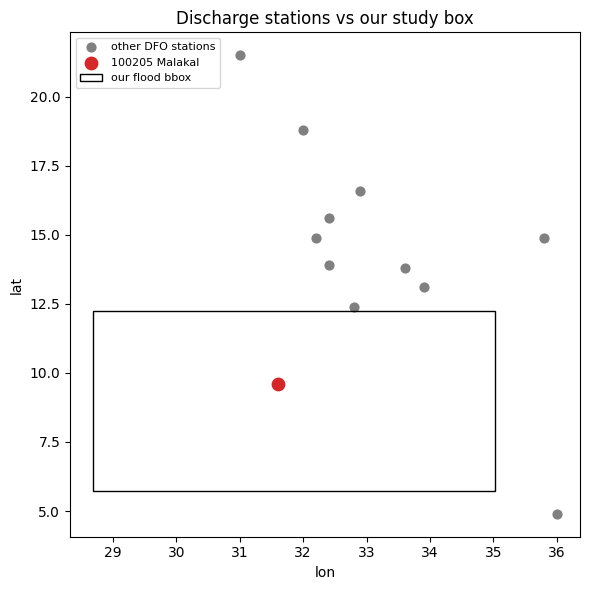

 area id  station nr     Country  latitude  longitude
  100205         334 South Sudan       9.6       31.6
    1541         224       Sudan      12.4       32.8
    1542         225       Sudan      13.9       32.4
    1543         226       Sudan      14.9       32.2
    1544         227       Sudan      13.1       33.9
    1545         228       Sudan      13.8       33.6
    1547         229       Sudan      15.6       32.4
    1548         230       Sudan      16.6       32.9
   11808         289       Sudan      18.8       32.0
   11842         290       Sudan      21.5       31.0
   28546         293       Sudan      14.9       35.8
    1505         217    Ethiopia       4.9       36.0


In [13]:
# all dartmouth points; 100205 is the SSD/Malakal one
info = pd.read_excel(DATA / "Darthmouth Flood Observatory" / "information.xlsx")
info = info.drop_duplicates("area id")

fig, ax = plt.subplots(figsize=(6, 6))
other = info[info["area id"] != STATION_ID]
ax.scatter(other["longitude"], other["latitude"], s=40, c="0.5", label="other DFO stations")
row = info[info["area id"] == STATION_ID].iloc[0]
ax.scatter([row["longitude"]], [row["latitude"]], s=80, c="C3", zorder=3, label="100205 Malakal")
ax.add_patch(Rectangle((BBOX["lon_min"], BBOX["lat_min"]),
                       BBOX["lon_max"]-BBOX["lon_min"], BBOX["lat_max"]-BBOX["lat_min"],
                       fill=False, label="our flood bbox"))
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title("Discharge stations vs our study box")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "11_all_gauges.png", dpi=140)
plt.show()
print(info[["area id", "station nr", "Country", "latitude", "longitude"]].to_string(index=False))


gauge 100205 n 120 r0 -0.776 r1 -0.793
Lake Victoria n 113 r0 0.349 r1 0.292
Lake Kyoga n 106 r0 0.311 r1 0.34
Lake Albert n 118 r0 0.44 r1 0.466
ERA5 rain tp n 120 r0 -0.451 r1 -0.338
ERA5 runoff ro n 120 r0 -0.369 r1 -0.212


,driver,r_same_month,r_driver_1m_earlier,n
0,gauge 100205,-0.775966,-0.792782,120
1,Lake Victoria,0.349394,0.291666,113
2,Lake Kyoga,0.310800,0.339966,106
3,Lake Albert,0.439783,0.465628,118
4,ERA5 rain tp,-0.451094,-0.337981,120
5,ERA5 runoff ro,-0.368555,-0.212157,120


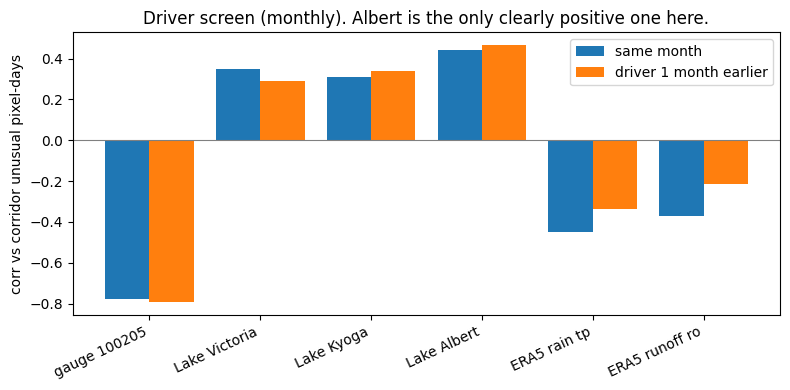

In [14]:
# reuse lake parser from earlier cells; extend victoria/kyoga to 2016-2025
lake_v_h = load_lake_txt("victoria").loc[str(HYDRO_YEARS[0]):str(HYDRO_YEARS[-1])]
lake_k_h = load_lake_txt("Kyoga").loc[str(HYDRO_YEARS[0]):str(HYDRO_YEARS[-1])]

# ERA5 rain and runoff, monthly mean in the same bbox (local wetness)
def era5_monthly(var, years):
    rows = []
    for year in years:
        path = DATA / "rainfall and runoff" / f"ERA5_{year}.nc"
        if not path.exists():
            continue
        ds = xr.open_dataset(path)
        da = ds[var]
        lat_name = "latitude" if "latitude" in da.coords else "lat"
        lon_name = "longitude" if "longitude" in da.coords else "lon"
        time_name = "valid_time" if "valid_time" in da.coords else "time"
        lat0 = float(da[lat_name][0])
        lat1 = float(da[lat_name][-1])
        lat_slice = slice(BBOX["lat_max"], BBOX["lat_min"]) if lat0 > lat1 else slice(BBOX["lat_min"], BBOX["lat_max"])
        sub = da.sel({lat_name: lat_slice, lon_name: slice(BBOX["lon_min"], BBOX["lon_max"])})
        monthly = (sub.mean(dim=[lat_name, lon_name]) * 1000).resample({time_name: "MS"}).mean()
        for t, val in zip(monthly[time_name].values, monthly.values):
            rows.append({"date": pd.to_datetime(t), var: float(val)})
        ds.close()
    s = pd.DataFrame(rows).drop_duplicates("date").set_index("date")[var].sort_index()
    return s

rain_h = era5_monthly("tp", HYDRO_YEARS)
ro_h = era5_monthly("ro", HYDRO_YEARS)

drivers = {
    "gauge 100205": q,
    "Lake Victoria": lake_v_h,
    "Lake Kyoga": lake_k_h,
    "Lake Albert": albert,
    "ERA5 rain tp": rain_h,
    "ERA5 runoff ro": ro_h,
}

rows = []
for name, series in drivers.items():
    d0 = overlay(unusual_cor, series, name)
    r0 = d0["flood"].corr(d0["driver"]) if len(d0) > 6 else float("nan")
    r1 = d0["flood"].corr(d0["driver"].shift(1)) if len(d0) > 6 else float("nan")
    rows.append({"driver": name, "r_same_month": r0, "r_driver_1m_earlier": r1, "n": len(d0)})
    print(name, "n", len(d0), "r0", None if pd.isna(r0) else round(r0, 3), "r1", None if pd.isna(r1) else round(r1, 3))

score = pd.DataFrame(rows)
score.to_csv(OUT / "driver_screen.csv", index=False)
display(score)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(score))
ax.bar([i - 0.2 for i in x], score["r_same_month"], width=0.4, label="same month")
ax.bar([i + 0.2 for i in x], score["r_driver_1m_earlier"], width=0.4, label="driver 1 month earlier")
ax.axhline(0, color="0.5", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(score["driver"], rotation=25, ha="right")
ax.set_ylabel("corr vs corridor unusual pixel-days")
ax.set_title("Driver screen (monthly). Albert is the only clearly positive one here.")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "12_driver_screen.png", dpi=140)
plt.show()
